# FIFA World Cup Analytics (2002–2022)

## Project Overview

This project analyzes FIFA World Cup tournaments from 2002 to 2022 using four datasets:

- Match Data
- Goal Data
- Squad Data
- Award Winners Data

The objective is to identify trends in team performance, goal scoring, player participation, and tournament awards across six World Cups (2002, 2006, 2010, 2014, 2018, and 2022).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
## Loading Datasets
###The datasets are loaded into separate DataFrames for further preprocessing and analysis.

matches= pd.read_csv("matches.csv")
goals = pd.read_csv("goals.csv")
squads = pd.read_csv("squads.csv")
awards = pd.read_csv("award_winners.csv")

## Dataset Dimensions
###The rows and columns in each dataset are inspected to understand their size and structure.

print("Matches:", matches.shape , matches.columns)
print("Goals:", goals.shape, goals.columns)
print("Squads:", squads.shape, squads.columns)
print("Awards:", awards.shape, awards.columns)

Matches: (1248, 37) Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'home_team_id', 'home_team_name',
       'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code',
       'score', 'home_team_score', 'away_team_score', 'home_team_score_margin',
       'away_team_score_margin', 'extra_time', 'penalty_shootout',
       'score_penalties', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object')
Goals: (3637, 27) Index(['key_id', 'goal_id', 'tournament_id', 'tournament_name', 'match_id',
       'match_name', 'match_date', 'stage_name', 'group_name', 'team_id',
       'team_name', 'team_code', 'home_team', 'away_team', 'player_id',
       'family_name', 'given_name', 'sh

## Filtering FIFA World Cups (2002–2022)

The original datasets contain information from multiple FIFA World Cup tournaments. For consistency, only tournaments held between 2002 and 2022 are retained.

In [16]:
# Convert match dates

matches["match_date"] = pd.to_datetime(matches["match_date"])
goals["match_date"] = pd.to_datetime(goals["match_date"])

# Extract year

matches["year"] = matches["match_date"].dt.year
goals["year"] = goals["match_date"].dt.year

# World Cup years included in the project

wc_years = [2002, 2006, 2010, 2014, 2018, 2022]

# Filter matches and goals

matches = matches[matches["year"].isin(wc_years)].copy()
goals = goals[goals["year"].isin(wc_years)].copy()

# Filter squads and awards using tournament names

pattern = "2002|2006|2010|2014|2018|2022"

squads = squads[
    squads["tournament_name"].astype(str).str.contains(pattern)
].copy()

awards = awards[
    awards["tournament_name"].astype(str).str.contains(pattern)
].copy()

print("Matches:", matches.shape)
print("Goals:", goals.shape)
print("Squads:", squads.shape)
print("Awards:", awards.shape)

print("World Cups Included:")
print(sorted(matches["year"].unique()))

Matches: (384, 38)
Goals: (965, 28)
Squads: (4511, 12)
Awards: (48, 12)
World Cups Included:
[np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022)]


In [17]:
# Displaying the filtered dataset

matches.head()

,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw,year
664,665,WC-2002,2002 FIFA Men's World Cup,M-2002-01,France vs Senegal,group stage,Group A,1,0,0,...,0,0,0-0,0,0,away team win,0,1,0,2002
665,666,WC-2002,2002 FIFA Men's World Cup,M-2002-02,Republic of Ireland vs Cameroon,group stage,Group E,1,0,0,...,0,0,0-0,0,0,draw,0,0,1,2002
666,667,WC-2002,2002 FIFA Men's World Cup,M-2002-03,Uruguay vs Denmark,group stage,Group A,1,0,0,...,0,0,0-0,0,0,away team win,0,1,0,2002
667,668,WC-2002,2002 FIFA Men's World Cup,M-2002-04,Germany vs Saudi Arabia,group stage,Group E,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,2002
668,669,WC-2002,2002 FIFA Men's World Cup,M-2002-05,Argentina vs Nigeria,group stage,Group F,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,2002


In [18]:
goals.head()

,key_id,goal_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,player_team_id,player_team_name,player_team_code,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty,year
2076,2077,G-2077,WC-2002,2002 FIFA Men's World Cup,M-2002-01,France vs Senegal,2002-05-31,group stage,Group A,T-65,...,T-65,Senegal,SEN,30',30,0,first half,0,0,2002
2077,2078,G-2078,WC-2002,2002 FIFA Men's World Cup,M-2002-02,Republic of Ireland vs Cameroon,2002-06-01,group stage,Group E,T-11,...,T-11,Cameroon,CMR,39',39,0,first half,0,0,2002
2078,2079,G-2079,WC-2002,2002 FIFA Men's World Cup,M-2002-02,Republic of Ireland vs Cameroon,2002-06-01,group stage,Group E,T-60,...,T-60,Republic of Ireland,IRL,52',52,0,second half,0,0,2002
2079,2080,G-2080,WC-2002,2002 FIFA Men's World Cup,M-2002-03,Uruguay vs Denmark,2002-06-01,group stage,Group A,T-22,...,T-22,Denmark,DNK,45',45,0,first half,0,0,2002
2080,2081,G-2081,WC-2002,2002 FIFA Men's World Cup,M-2002-03,Uruguay vs Denmark,2002-06-01,group stage,Group A,T-84,...,T-84,Uruguay,URY,47',47,0,second half,0,0,2002


In [19]:
squads.head()

,key_id,tournament_id,tournament_name,team_id,team_name,team_code,player_id,family_name,given_name,shirt_number,position_name,position_code
7238,7239,WC-2002,2002 FIFA Men's World Cup,T-03,Argentina,ARG,P-56385,Burgos,Germán,1,goal keeper,GK
7239,7240,WC-2002,2002 FIFA Men's World Cup,T-03,Argentina,ARG,P-83403,Ayala,Roberto,2,defender,DF
7240,7241,WC-2002,2002 FIFA Men's World Cup,T-03,Argentina,ARG,P-60914,Sorín,Juan Pablo,3,defender,DF
7241,7242,WC-2002,2002 FIFA Men's World Cup,T-03,Argentina,ARG,P-31684,Pochettino,Mauricio,4,defender,DF
7242,7243,WC-2002,2002 FIFA Men's World Cup,T-03,Argentina,ARG,P-88203,Almeyda,Matías,5,midfielder,MF


In [21]:
awards.head()

,key_id,tournament_id,tournament_name,award_id,award_name,shared,player_id,family_name,given_name,team_id,team_name,team_code
114,115,WC-2002,2002 FIFA Men's World Cup,A-1,Golden Ball,0,P-33751,Kahn,Oliver,T-31,Germany,DEU
115,116,WC-2002,2002 FIFA Men's World Cup,A-2,Silver Ball,0,P-62722,Ronaldo,not applicable,T-09,Brazil,BRA
116,117,WC-2002,2002 FIFA Men's World Cup,A-3,Bronze Ball,0,P-55097,Hong,Myung-bo,T-71,South Korea,KOR
117,118,WC-2002,2002 FIFA Men's World Cup,A-4,Golden Boot,0,P-62722,Ronaldo,not applicable,T-09,Brazil,BRA
118,119,WC-2002,2002 FIFA Men's World Cup,A-5,Silver Boot,1,P-27787,Klose,Miroslav,T-31,Germany,DEU


## Data Quality Assessment

Before performing any analysis, the datasets are inspected for missing values, duplicate records, and data consistency issues.

This step helps ensure that the analysis is based on reliable and accurate data.

In [22]:
datasets = {
    "Matches": matches,
    "Goals": goals,
    "Squads": squads,
    "Awards": awards
}

for name, data in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)

    print("\nShape:")
    print(data.shape)

    print("\nMissing Values:")
    print(data.isnull().sum().sum())

    print("\nDuplicate Rows:")
    print(data.duplicated().sum())

    print("\n")

Matches

Shape:
(384, 38)

Missing Values:
0

Duplicate Rows:
0


Goals

Shape:
(965, 28)

Missing Values:
0

Duplicate Rows:
0


Squads

Shape:
(4511, 12)

Missing Values:
0

Duplicate Rows:
0


Awards

Shape:
(48, 12)

Missing Values:
0

Duplicate Rows:
0




## Handling Missing Values and Duplicate Records

The datasets were examined for missing values and duplicate records as part of the data quality assessment process.

In this project, no missing values or duplicate rows were found across the Matches, Goals, Squads, and Awards datasets. Therefore, no data cleaning operations were required.

If missing values had been present, the following approaches would have been considered depending on the nature of the data:

- Removing rows containing missing values when the affected records were few in number.
- Imputing missing numerical values using statistical measures such as the mean or median.
- Replacing missing categorical values with the mode or an appropriate placeholder category.
- Investigating the source of missing data to determine whether it represented a meaningful absence of information.

Similarly, if duplicate records had been detected, duplicate rows would have been removed to prevent double-counting during analysis and visualization.

Performing these checks ensures the reliability and accuracy of the subsequent analysis.

## Feature Engineering

Feature engineering involves creating new variables from existing data to support deeper analysis and visualization.
For the Matches dataset, additional metrics such as total goals, goal difference, and match outcome categories are generated.
These engineered features will be used throughout the analysis and Power BI dashboard development.

In [25]:

# Total goals scored in each match
matches["total_goals"] = (
    matches["home_team_score"] +
    matches["away_team_score"]
)

# Absolute goal difference
matches["goal_difference"] = abs(
    matches["home_team_score"] -
    matches["away_team_score"]
)

# Match outcome category
matches["match_result"] = np.select(
    [
        matches["home_team_win"] == 1,
        matches["away_team_win"] == 1,
        matches["draw"] == 1
    ],
    [
        "Home Win",
        "Away Win",
        "Draw"
    ],
    default="Unknown"
)

# Full player name
squads["player_name"] = np.where(
    squads["given_name"].isin(["Not Applicable", "not applicable"]),
    squads["family_name"],
    squads["given_name"] + " " + squads["family_name"]
)

# Full award winner name
awards["winner_name"] = np.where(
    awards["given_name"].fillna("").str.lower().isin(["not applicable", ""]),
    awards["family_name"],
    awards["given_name"] + " " + awards["family_name"]
)

awards["winner_name"] = awards["winner_name"].str.strip()

# VERIFICATION

print("Feature Engineering Completed Successfully")

print("\nMatches Features:")
print(matches[["total_goals", "goal_difference", "match_result"]].head())

print("\nSquads Features:")
print(squads[["player_name"]].head())

print("\nAwards Features:")
print(awards[["winner_name"]].head())

Feature Engineering Completed Successfully

Matches Features:
     total_goals  goal_difference match_result
664            1                1     Away Win
665            2                0         Draw
666            3                1     Away Win
667            8                8     Home Win
668            1                1     Home Win

Squads Features:
              player_name
7238        Germán Burgos
7239        Roberto Ayala
7240     Juan Pablo Sorín
7241  Mauricio Pochettino
7242       Matías Almeyda

Awards Features:
        winner_name
114     Oliver Kahn
115         Ronaldo
116   Myung-bo Hong
117         Ronaldo
118  Miroslav Klose


## World Cup Overview (2002–2022)

This section provides a high-level overview of FIFA World Cup tournaments held between 2002 and 2022.

Key performance indicators (KPIs) such as total matches, total goals, average goals per match, participating teams, and tournaments are calculated to understand the overall scale and scoring trends of the competitions.

In [32]:
# Tournament KPIs

total_matches = matches.shape[0]

total_goals = goals.shape[0]

avg_goals_per_match = round(total_goals / total_matches, 2)

num_tournaments = matches["year"].nunique()

num_teams = pd.concat([
    matches["home_team_name"],
    matches["away_team_name"]
]).nunique()

print(f"Total Matches: {total_matches}")
print(f"Total Goals: {total_goals}")
print(f"Average Goals per Match: {avg_goals_per_match}")
print(f"Number of Tournaments: {num_tournaments}")

Total Matches: 384
Total Goals: 965
Average Goals per Match: 2.51
Number of Tournaments: 6


## Tournament-Level Analysis

To compare FIFA World Cups from 2002 to 2022, tournament-level metrics are calculated for each edition.

The analysis includes:
- Number of matches
- Total goals scored
- Average goals per match
- Participating teams

In [49]:
# Final matches 
finals = matches[matches["stage_name"] == "Final"].copy()

# Determine champion
finals["champion"] = np.where(
    finals["home_team_win"] == 1,
    finals["home_team_name"],
    finals["away_team_name"]
)

# Host country for each tournament
host_country = (
    matches.groupby("year")["country_name"]
    .first()
    .reset_index()
)

# Tournament summary
tournament_summary = (
    matches.groupby("year")
    .agg(
        matches=("match_id", "count"),
        total_goals=("total_goals", "sum"),
    )
    .reset_index()
)

tournament_summary["avg_goals_per_match"] = (
    tournament_summary["total_goals"]
    / tournament_summary["matches"]
).round(2)

# Add champion
tournament_summary = tournament_summary.merge(
    finals[["year", "champion"]],
    on="year",
    how="left"
)

# Add host country
tournament_summary = tournament_summary.merge(
    host_country,
    on="year",
    how="left"
)

# Rename column
tournament_summary.rename(
    columns={"country_name": "host_country"},
    inplace=True
)

# Reorder columns
tournament_summary = tournament_summary[
    [
        "year",
        "host_country",
        "matches",
        "total_goals",
        "avg_goals_per_match"
    ]
]
finals = matches[matches["stage_name"] == "final"].copy()
finals["champions"] = np.where(
    finals["home_team_win"] == 1,
    finals["home_team_name"],
    finals["away_team_name"]
)

finals[["year", "champions"]]
tournament_summary = tournament_summary.merge(
    finals[["year", "champions"]],
    on="year",
    how="left"
)

tournament_summary

,year,host_country,matches,total_goals,avg_goals_per_match,champions
0,2002,South Korea,64,161,2.52,Brazil
1,2006,Germany,64,147,2.30,Italy
2,2010,South Africa,64,145,2.27,Spain
3,2014,Brazil,64,171,2.67,Germany
4,2018,Russia,64,169,2.64,France
5,2022,Qatar,64,172,2.69,Argentina


### Goals by World Cup Year

To identify scoring trends across tournaments, the total number of goals scored in each FIFA World Cup is calculated and visualized.

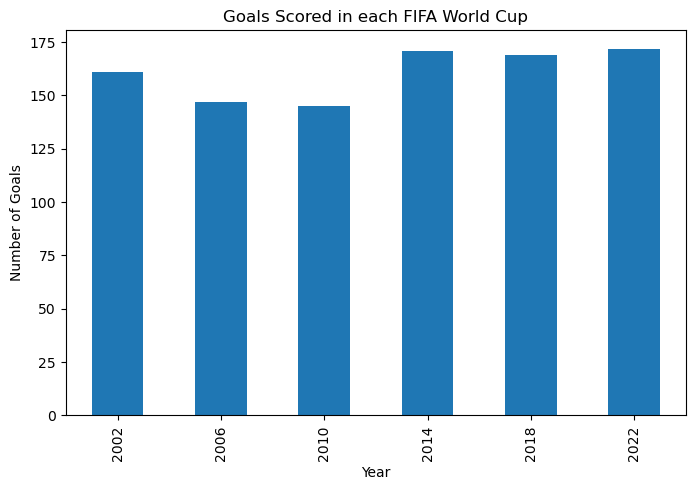

In [30]:
goals_by_year = goals.groupby("year").size()

plt.figure(figsize=(8,5))
goals_by_year.plot(kind="bar")

plt.title("Goals Scored in each FIFA World Cup")
plt.xlabel("Year")
plt.ylabel("Number of Goals")

plt.show()

In [ ]:
### Observation

The total number of goals scored varied across tournaments. The comparison highlights differences in attacking output
and overall scoring trends between World Cups from 2002 to 2022.

Further analysis will examine average goals per match to account for differences in tournament structure and scoring efficiency.


In [ ]:
### Highest Scoring Tournaments

The average number of goals scored per match is calculated for each FIFA World Cup to compare offensive output across tournaments.

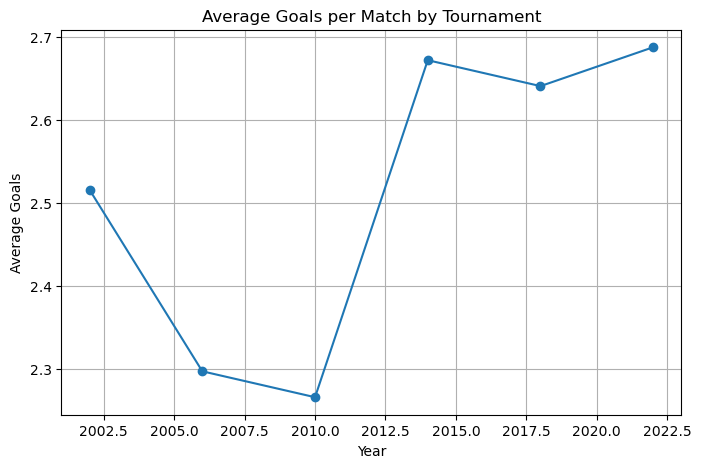

In [29]:
avg_goals = (
    matches.groupby("year")["total_goals"]
    .mean()
)

plt.figure(figsize=(8,5))
avg_goals.plot(marker="o")

plt.title("Average Goals per Match by Tournament")
plt.xlabel("Year")
plt.ylabel("Average Goals")

plt.grid(True)

plt.show()

In [53]:
matches.to_csv("matches_cleaned.csv", index=False)
goals.to_csv("goals_cleaned.csv", index=False)
squads.to_csv("squads_cleaned.csv", index=False)
awards.to_csv("awards_cleaned.csv", index=False)

In [51]:
import os
print(os.getcwd())
os.listdir()

/drive/notebooks


['Untitled.ipynb',
 'award_winners.csv',
 'goals.csv',
 'matches.csv',
 'squads.csv',
 'cpp-tiny-ray-tracer.ipynb',
 'cpp-third-party-libs.ipynb',
 'Lorenz.ipynb',
 'cpp.ipynb',
 'r.ipynb',
 'Intro.ipynb',
 'sqlite.ipynb']

## Team Performance Analysis (2002–2022)

This section analyzes how teams performed across FIFA World Cups from 2002 to 2022.

We evaluate:
- Total wins per team
- Goals scored by each team
- Match outcomes (wins, losses, draws)
- Overall dominance in World Cup history

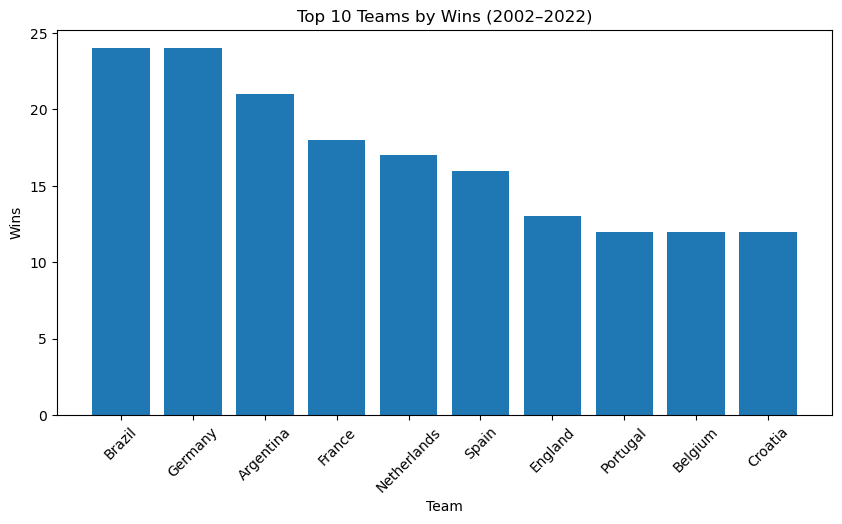

In [55]:
# Home team performance
home = matches[[
    "year", "home_team_name", "home_team_score",
    "away_team_score", "home_team_win", "draw"
]].copy()

home.columns = [
    "year", "team", "goals_for", "goals_against",
    "win", "draw"
]

home["loss"] = (home["win"] == 0) & (home["draw"] == 0)


# Away team performance
away = matches[[
    "year", "away_team_name", "away_team_score",
    "home_team_score", "away_team_win", "draw"
]].copy()

away.columns = [
    "year", "team", "goals_for", "goals_against",
    "win", "draw"
]

away["loss"] = (away["win"] == 0) & (away["draw"] == 0)

# Combine both
team_perf = pd.concat([home, away])

team_perf.head()

team_summary = team_perf.groupby("team").agg(
    matches=("team", "count"),
    wins=("win", "sum"),
    draws=("draw", "sum"),
    losses=("loss", "sum"),
    goals_scored=("goals_for", "sum"),
    goals_conceded=("goals_against", "sum")
)

team_summary["goal_difference"] = (
    team_summary["goals_scored"] - team_summary["goals_conceded"]
)

team_summary["win_rate"] = (
    team_summary["wins"] / team_summary["matches"]
).round(2)

team_summary.sort_values("wins", ascending=False).head(10)

top_teams = team_summary.sort_values("wins", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_teams.index, top_teams["wins"])

plt.title("Top 10 Teams by Wins (2002–2022)")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)
plt.show()

In [56]:
# --- HOME SIDE ---
home = matches[[
    "year", "home_team_name", "home_team_score", "away_team_score",
    "home_team_win", "draw"
]].copy()

home.columns = ["year", "team", "goals_for", "goals_against", "win", "draw"]

home["loss"] = (home["win"] == 0) & (home["draw"] == 0)


# --- AWAY SIDE ---
away = matches[[
    "year", "away_team_name", "away_team_score", "home_team_score",
    "away_team_win", "draw"
]].copy()

away.columns = ["year", "team", "goals_for", "goals_against", "win", "draw"]

away["loss"] = (away["win"] == 0) & (away["draw"] == 0)


# --- COMBINE ---
team_data = pd.concat([home, away])


# --- TEAM SUMMARY ---
team_summary = team_data.groupby("team").agg(
    matches=("team", "count"),
    wins=("win", "sum"),
    draws=("draw", "sum"),
    losses=("loss", "sum"),
    goals_scored=("goals_for", "sum"),
    goals_conceded=("goals_against", "sum")
)

# Goal difference
team_summary["goal_difference"] = (
    team_summary["goals_scored"] - team_summary["goals_conceded"]
)

# Win rate
team_summary["win_rate"] = (
    team_summary["wins"] / team_summary["matches"]
).round(2)

team_summary.sort_values("wins", ascending=False)

,matches,wins,draws,losses,goals_scored,goals_conceded,goal_difference,win_rate
team,,,,,,,,
Brazil,34,24,3,7,64,30,34,0.71
Germany,34,24,3,7,70,27,43,0.71
Argentina,31,21,3,7,52,32,20,0.68
France,32,18,6,8,50,27,23,0.56
Netherlands,23,17,2,4,40,16,24,0.74
...,...,...,...,...,...,...,...,...
New Zealand,3,0,3,0,2,2,0,0.00
North Korea,3,0,0,3,1,12,-11,0.00
Panama,3,0,0,3,2,11,-9,0.00


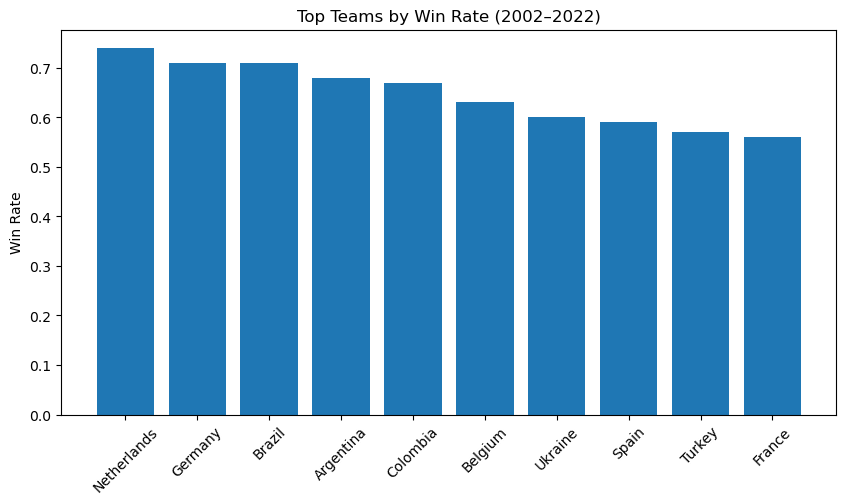

In [58]:
team_analysis = team_summary.copy()
top_winrate = team_analysis.sort_values(
    "win_rate", ascending=False
).head(10)

top_winrate[["win_rate"]]

top10 = top_winrate.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10["win_rate"])

plt.title("Top Teams by Win Rate (2002–2022)")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)

plt.show()

## Goal Type Distribution (2002–2022)

This section analyzes how goals were scored in FIFA World Cups from 2002 to 2022.

We categorize goals into:
- Open Play Goals
- Penalty Goals
- Own Goals

This helps understand the nature of scoring in World Cup matches and whether goals are mostly structured play, set-pieces, or errors.

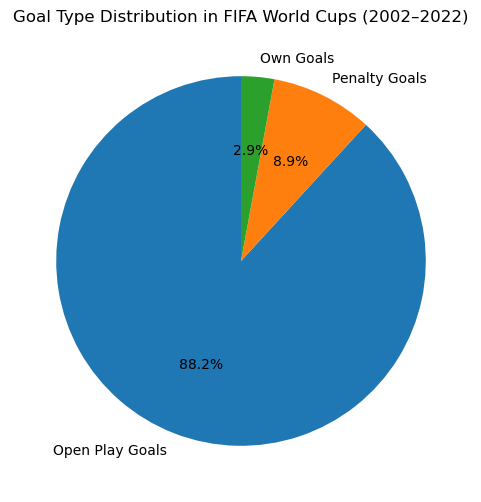

In [69]:
# Ensure boolean columns are clean
goals["penalty"] = goals["penalty"].fillna(False)
goals["own_goal"] = goals["own_goal"].fillna(False)

goal_types = pd.DataFrame({
    "Goal Type": [
        "Open Play Goals",
        "Penalty Goals",
        "Own Goals"
    ],
    "Count": [
        len(goals[(goals["penalty"] == False) & (goals["own_goal"] == False)]),
        len(goals[goals["penalty"] == True]),
        len(goals[goals["own_goal"] == True])
    ]
})

goal_types

plt.figure(figsize=(6,6))

plt.pie(
    goal_types["Count"],
    labels=goal_types["Goal Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Goal Type Distribution in FIFA World Cups (2002–2022)")
plt.show()

## Player Analysis (2002–2022)

This section evaluates individual player performance in FIFA World Cups from 2002 to 2022.

### Top Goal Scorers

We identify the players with the highest number of goals scored across all FIFA World Cups between 2002 and 2022.

In [64]:
goals["given_name"] = goals["given_name"].astype(str).str.strip()

goals.loc[
    goals["given_name"].str.lower().eq("not applicable"),
    "given_name"
] = np.nan
goals["player_name"] = (
    goals["given_name"].fillna("") + " " +
    goals["family_name"].fillna("")
).str.strip()

goals["player_name"] = goals["player_name"].str.strip()
top_scorers = goals.groupby("player_name").agg(
    goals_scored=("goal_id", "count")
).sort_values("goals_scored", ascending=False)

top_scorers.head(10)

,goals_scored
player_name,
Miroslav Klose,16
Lionel Messi,13
Kylian Mbappé,12
Ronaldo,11
Thomas Müller,10
David Villa,9
Cristiano Ronaldo,8
Harry Kane,8
Neymar,8


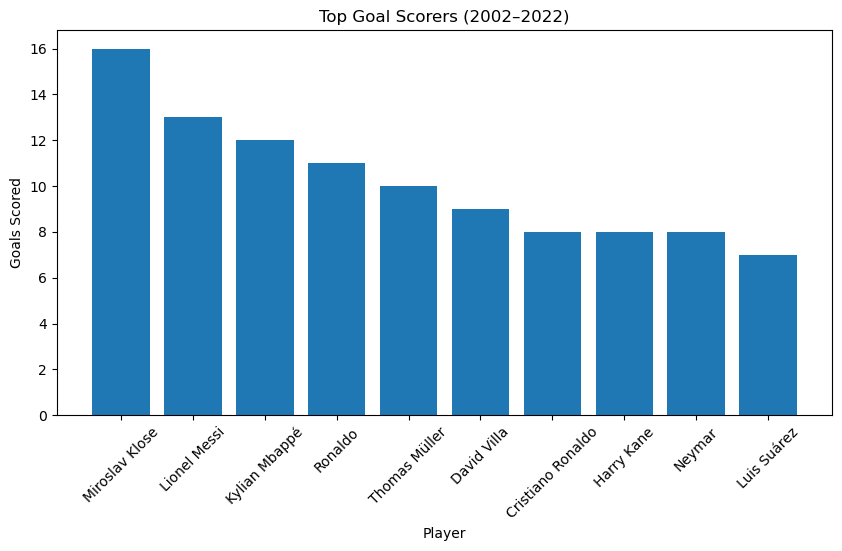

In [65]:
top10 = top_scorers.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10.index, top10["goals_scored"])

plt.title("Top Goal Scorers (2002–2022)")
plt.xlabel("Player")
plt.ylabel("Goals Scored")
plt.xticks(rotation=45)

plt.show()

In [ ]:
### Player Consistency (Appearances)

To understand consistency, we analyze how many different matches each player has scored in.


In [66]:
player_consistency = goals.groupby("player_name").agg(
    matches_scored_in=("match_id", "nunique"),
    goals_scored=("goal_id", "count")
).sort_values("matches_scored_in", ascending=False)

player_consistency.head(10)

,matches_scored_in,goals_scored
player_name,,
Miroslav Klose,11,16
Lionel Messi,11,13
Ronaldo,8,11
David Villa,7,9
Kylian Mbappé,7,12
Thomas Müller,7,10
Neymar,6,8
Asamoah Gyan,6,6
Cristiano Ronaldo,6,8


## Awards by Tournament (2002–2022)

This section identifies major FIFA World Cup awards for each tournament:
- Golden Boot (top scorer)
- Golden Ball (best player)
- Golden Glove (best goalkeeper)

This helps compare standout performers across different World Cups.

In [68]:
# standardize text
awards["given_name"] = awards["given_name"].astype(str).str.strip()
awards["family_name"] = awards["family_name"].astype(str).str.strip()

# convert bad values to NaN
awards.loc[
    awards["given_name"].str.lower().isin(["not applicable", "nan", "none", ""]),
    "given_name"
] = np.nan

# rebuild clean name
awards["winner_name"] = (
    awards["given_name"].fillna("") + " " +
    awards["family_name"].fillna("")
).str.strip()

# --- GOLDEN BOOT ---
golden_boot = awards[awards["award_name_clean"].str.contains("golden boot")][
    ["tournament_name", "winner_name"]
].rename(columns={"winner_name": "golden_boot"})


# --- GOLDEN BALL ---
golden_ball = awards[awards["award_name_clean"].str.contains("golden ball")][
    ["tournament_name", "winner_name"]
].rename(columns={"winner_name": "golden_ball"})


# --- GOLDEN GLOVE ---
golden_glove = awards[awards["award_name_clean"].str.contains("golden glove")][
    ["tournament_name", "winner_name"]
].rename(columns={"winner_name": "golden_glove"})


# --- EMERGING / YOUNG PLAYER ---
emerging_player = awards[awards["award_name_clean"].str.contains("young")][
    ["tournament_name", "winner_name"]
].rename(columns={"winner_name": "emerging_player"})


# --- MERGE ALL ---
award_summary = golden_boot.merge(golden_ball, on="tournament_name", how="outer") \
    .merge(golden_glove, on="tournament_name", how="outer") \
    .merge(emerging_player, on="tournament_name", how="outer")


# --- Clean column name ---
award_summary = award_summary.rename(columns={"tournament_name": "year"})

award_summary

,year,golden_boot,golden_ball,golden_glove,emerging_player
0,2002 FIFA Men's World Cup,Ronaldo,Oliver Kahn,Oliver Kahn,Landon Donovan
1,2006 FIFA Men's World Cup,Miroslav Klose,Zinedine Zidane,Gianluigi Buffon,Lukas Podolski
2,2010 FIFA Men's World Cup,Thomas Müller,Diego Forlán,Iker Casillas,Thomas Müller
3,2014 FIFA Men's World Cup,James Rodríguez,Lionel Messi,Manuel Neuer,Paul Pogba
4,2018 FIFA Men's World Cup,Harry Kane,Luka Modrić,Thibaut Courtois,Kylian Mbappé
5,2022 FIFA Men's World Cup,Kylian Mbappé,Lionel Messi,Emiliano Martínez,Enzo Fernández
